In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go


In [2]:
df = pd.read_csv("/Titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [20]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
df['Age'] = df['Age'].fillna(df['Age'].median()) #fill missing Age values using the median because age can contain outliers

In [23]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) #Embarked, use the most frequent value:

In [24]:
df['CabinAvailable'] = df['Cabin'].notna().astype(int) #we can create a new column indicating whether cabin information was available.

In [26]:
df .isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Q1. Create a countplot to show the number of passengers by gender.

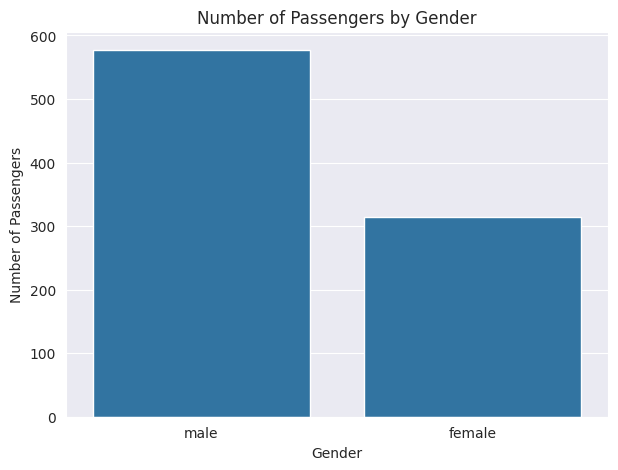

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Sex')

plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

Interpretation

The countplot shows that male passengers (577) were more numerous than female passengers (314) in the Titanic dataset. Therefore, the dataset contains a larger proportion of male passengers.

Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

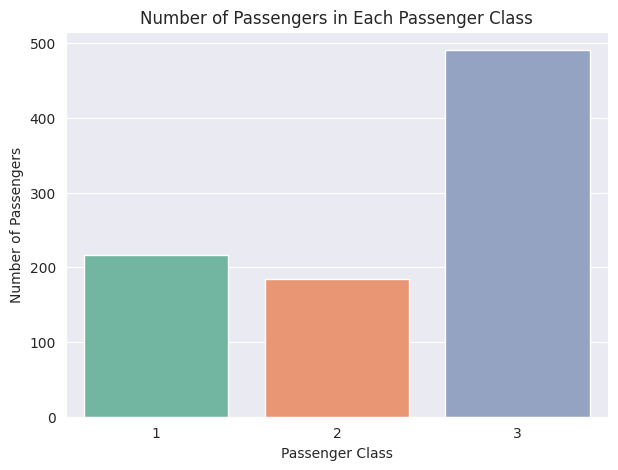

In [28]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=df['Pclass'].value_counts().sort_index().index,
    y=df['Pclass'].value_counts().sort_index().values,
    hue=df['Pclass'].value_counts().sort_index().index,
    palette='Set2',
    legend=False
)

plt.title('Number of Passengers in Each Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

Interpretation

The bar chart shows that 3rd class had the highest number of passengers, followed by 2nd class, while 1st class had the fewest passengers.

Q3. Create a histogram to show the distribution of passenger age.

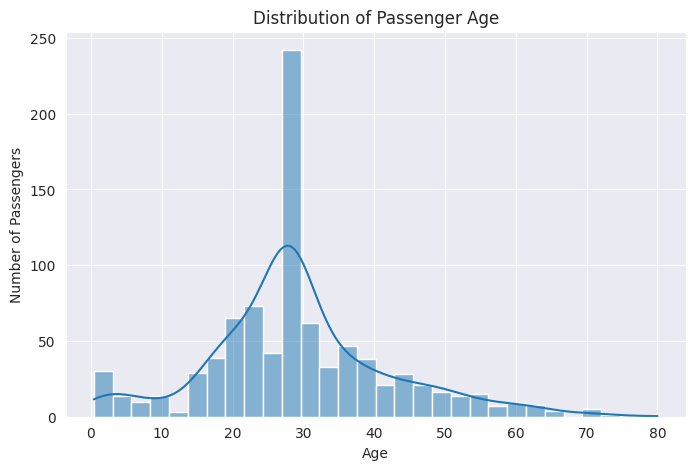

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=30, kde=True)

plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

Interpretation

The histogram shows the distribution of passenger ages. Most passengers were young to middle-aged, with a larger concentration roughly between 20 and 40 years. The number of passengers decreases at older ages.

Q4. Create a boxplot to detect outliers in the fare column.

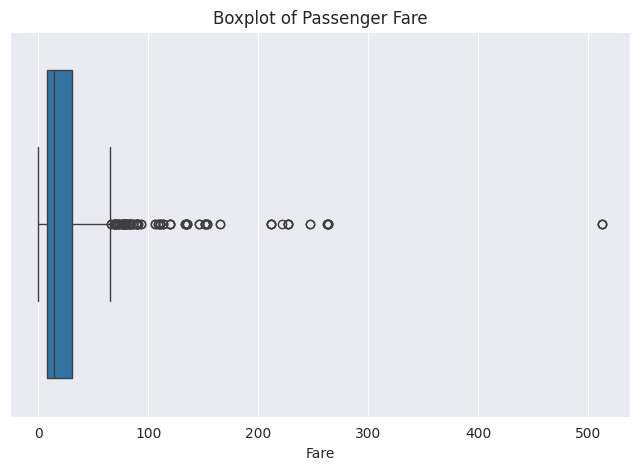

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Fare')

plt.title('Boxplot of Passenger Fare')
plt.xlabel('Fare')

plt.show()

Interpretation

The boxplot shows the distribution of passenger fares and helps identify outliers. The points beyond the upper whisker represent passengers who paid unusually high fares compared with most passengers

Q5. Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare.

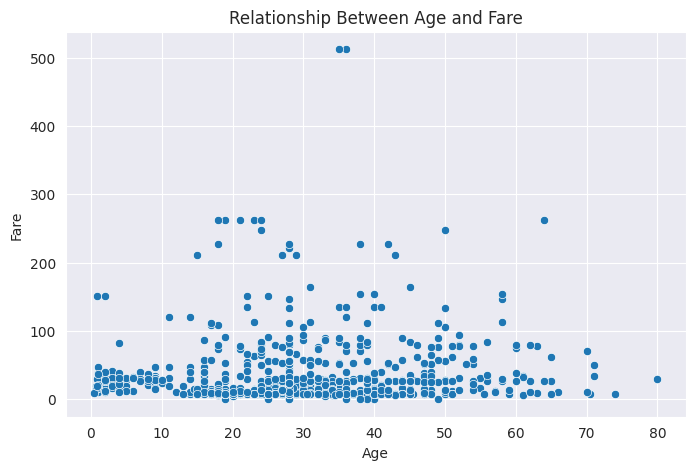

In [31]:
# a. Relationship between Age and Fare

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Age', y='Fare')

plt.title('Relationship Between Age and Fare')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

Interpretation

The scatterplot shows the relationship between passenger age and fare. There is no strong direct relationship between age and fare. However, a few passengers paid very high fares, which appear as outliers.

In [32]:
# b. Relationship between Family Size and Fare
df['FamilySize'] = df['SibSp'] + df['Parch']

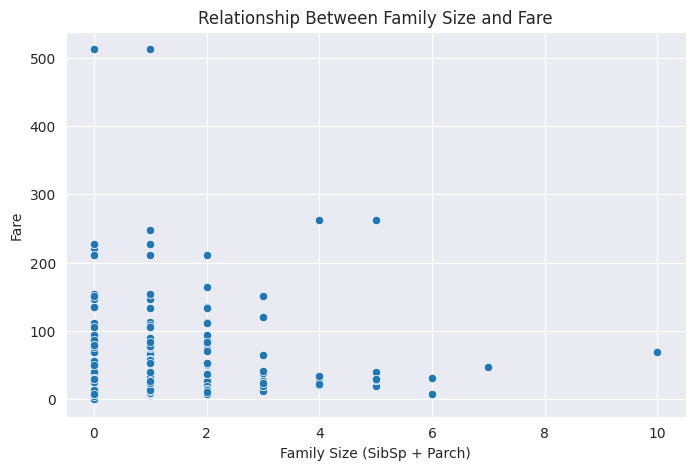

In [33]:
# Then create the scatterplot:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='FamilySize', y='Fare')

plt.title('Relationship Between Family Size and Fare')
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Fare')

plt.show()

Interpretation

The scatterplot shows that there is no strong linear relationship between family size and fare. Most passengers with different family sizes paid relatively low fares, while some passengers with larger family sizes paid higher fares. The high-fare points are also influenced by passenger class and ticket characteristics.

Q6. Create a countplot to show survival count by gender.

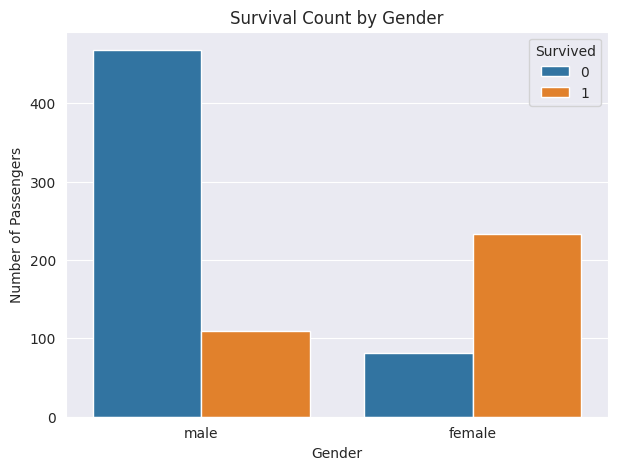

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

Interpretation

The countplot shows the number of survived and non-survived passengers by gender. Female passengers had a much higher number of survivors compared with male passengers, while male passengers had a much higher number of deaths.

Q7. Create a bar chart to show survival by passenger class.

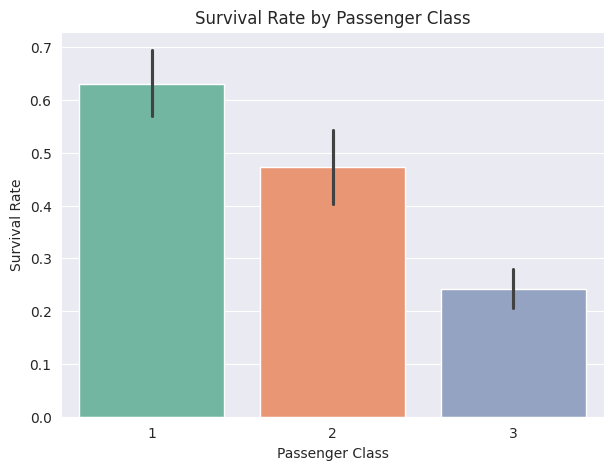

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='Set2', legend=False)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

Interpretation

The bar chart shows that 1st-class passengers had the highest survival rate, followed by 2nd class, while 3rd-class passengers had the lowest survival rate. This indicates that passenger class had a strong relationship with survival.

Q8. Create a heatmap to show correlation between numerical variables.


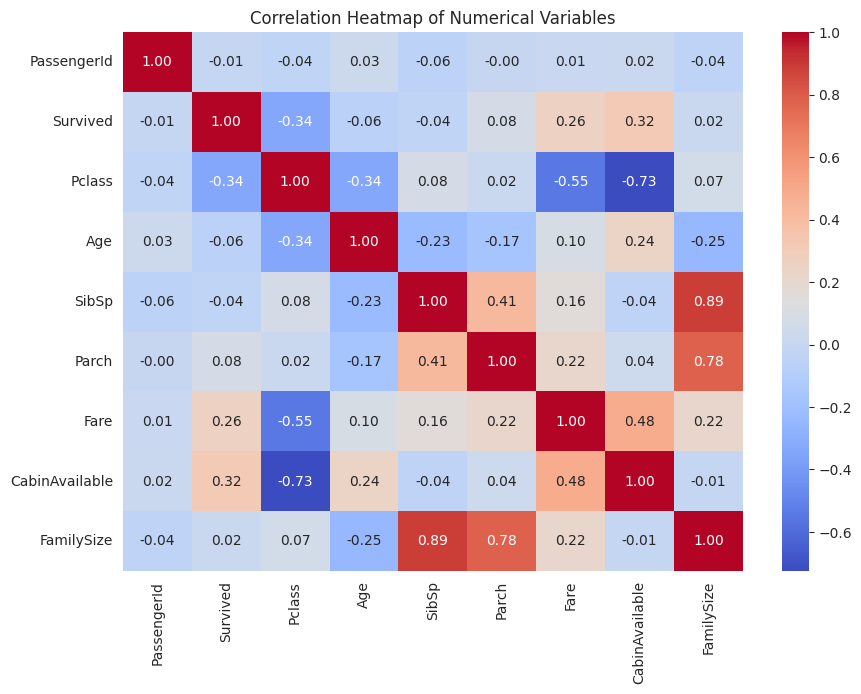

In [36]:
plt.figure(figsize=(10, 7))

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Create correlation matrix
correlation = numeric_df.corr()

# Create heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

Interpretation

The heatmap shows the correlation between numerical variables in the Titanic dataset.

Pclass and Fare have a negative correlation, meaning higher-class numbers (especially 3rd class) are generally associated with lower fares.
Pclass and Survived also have a negative correlation, indicating that passengers in higher-numbered classes had lower survival rates.
Fare and Survived have a positive correlation, meaning passengers who paid higher fares generally had a greater chance of survival.
SibSp and Parch have a positive relationship because both represent family-related information.

Q9. Identify which passenger class paid the highest fare on average.



In [40]:
# Calculate average fare for each passenger class
average_fare = df.groupby('Pclass')['Fare'].mean()
average_fare

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


In [41]:
import builtins
print = builtins.print # Restore the built-in print function

highest_fare_class = average_fare.idxmax()
highest_average_fare = average_fare.max()

print("Passenger Class with Highest Average Fare:", highest_fare_class)
print("Highest Average Fare:", highest_average_fare)

Passenger Class with Highest Average Fare: 1
Highest Average Fare: 84.1546875


Interpretation

First-class passengers paid substantially higher fares on average than second- and third-class passengers. This is consistent with the higher level of accommodation and services associated with first-class travel.

Q10. Write at least 5 insights from the dataset based on your visualizations.

1.Gender strongly affected survival: Female passengers had a much higher survival rate than male passengers.

2.Age had a varied distribution: Most passengers were young or middle-aged, with fewer passengers at older ages.


3.First-class passengers paid the highest average fare: The average fare for 1st-class passengers was much higher than for 2nd- and 3rd-class passengers.

4.3rd class had the most passengers: Most passengers in the dataset belonged to 3rd class.

5. Passenger class affected survival: 1st-class passengers had the highest survival rate, while 3rd-class passengers had the lowest.